## Environment setup
Run this cell first after starting the runtime to pin compatible dependencies before importing TensorFlow. It prevents the `empty_like` docstring error caused by the default NumPy 2.x release when loading tf.keras and TensorFlow Model Optimization.

In [8]:
# Install pinned NumPy/Pandas wheels to avoid ABI conflicts in Colab
# !pip install -q --no-cache-dir --force-reinstall numpy==1.26.4 pandas==2.2.2


In [9]:
import pandas as pd
from pathlib import Path

# Import Data
We need to concatenate all readings from all csvs into a single DataFrame.

In [10]:
# CODEX: load only root measurements CSV files whose names contain 'measurements'
repo_root_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
repo_root = next((path for path in repo_root_candidates if (path / 'measurements').is_dir()), None)
if repo_root is None:
    raise FileNotFoundError(f"Could not find the repo root measurements directory. Checked: {repo_root_candidates}")

data_dir = repo_root / 'measurements'
csv_files = sorted(data_dir.glob('*measurements*.csv'))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_dir}")

excluded_files = {'measurements_2000-01-01.csv'}
dfs = []
skipped_files = []
for csv_file in csv_files:
    if csv_file.name in excluded_files:
        skipped_files.append((csv_file.name, 'excluded file'))
        continue
    if csv_file.stat().st_size == 0:
        skipped_files.append((csv_file.name, 'empty file'))
        continue
    try:
        df_temp = pd.read_csv(csv_file)
    except pd.errors.EmptyDataError:
        skipped_files.append((csv_file.name, 'no columns to parse'))
        continue
    dfs.append(df_temp)

if not dfs:
    raise ValueError(f"No readable CSV files found in {data_dir}")

df = pd.concat(dfs, ignore_index=True)
print(f"Loaded data from: {data_dir.resolve()}")
print("Filename filter: *measurements*.csv")
print(f"Successfully loaded and concatenated {len(dfs)} CSV files into a single DataFrame.")
if skipped_files:
    print(f"Skipped {len(skipped_files)} files: {skipped_files}")
print(f"The final DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Loaded data from: /Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/measurements
Filename filter: *measurements*.csv
Successfully loaded and concatenated 117 CSV files into a single DataFrame.
Skipped 1 files: [('measurements_2000-01-01.csv', 'excluded file')]
The final DataFrame has 3710084 rows and 10 columns.


,timestamp_iso8601,sensor,quantity,value,unit,datetime,voltage,current,power_factor,model_name
0,2025-09-04T22:13:36Z,veml7700,lux_lx,26.342400,lx,NaN,NaN,NaN,NaN,NaN
1,2025-09-04T22:13:37Z,bme280,temperature_c,29.042791,degC,NaN,NaN,NaN,NaN,NaN
2,2025-09-04T22:13:37Z,bme280,pressure_pa,100963.773438,Pa,NaN,NaN,NaN,NaN,NaN
3,2025-09-04T22:13:37Z,bme280,humidity_pct,64.752380,pct,NaN,NaN,NaN,NaN,NaN
4,2025-09-04T22:13:43Z,lm393,is_raining,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df[["timestamp_iso8601", "quantity", "value"]]
df.head()

,timestamp_iso8601,quantity,value
0,2025-09-04T22:13:36Z,lux_lx,26.342400
1,2025-09-04T22:13:37Z,temperature_c,29.042791
2,2025-09-04T22:13:37Z,pressure_pa,100963.773438
3,2025-09-04T22:13:37Z,humidity_pct,64.752380
4,2025-09-04T22:13:43Z,is_raining,0.000000


# Data Pre-Processing

## Pivoting - Reformating the data into multiple columns
We make each quantity (measurement type e.g. lux, pressure, temperature) its own column, so each row will have one value per quantity instead of one row per quantity.

In [12]:
df["quantity"].value_counts()

quantity
temperature_c    877598
humidity_pct     868804
pressure_pa      802999
lux_lx           781401
is_raining       379277
Name: count, dtype: int64

In [13]:
df = df.pivot_table(values='value', index='timestamp_iso8601',
                       columns='quantity', aggfunc="mean").reset_index()
print(df.columns.name)
df.head()

quantity


quantity,timestamp_iso8601,humidity_pct,is_raining,lux_lx,pressure_pa,temperature_c
0,2025-09-04T22:13:36Z,NaN,NaN,26.342400,NaN,NaN
1,2025-09-04T22:13:37Z,64.752380,NaN,NaN,100963.773438,29.042791
2,2025-09-04T22:13:43Z,64.420753,0.0,27.417599,100968.562500,29.022619
3,2025-09-04T22:13:52Z,NaN,0.0,NaN,NaN,NaN
4,2025-09-04T22:13:53Z,64.489609,NaN,NaN,100961.906250,28.982277


In [14]:
df.columns.name = None

In [15]:
df = df.drop(["is_raining"], axis=1)
df.head()

,timestamp_iso8601,humidity_pct,lux_lx,pressure_pa,temperature_c
0,2025-09-04T22:13:36Z,NaN,26.342400,NaN,NaN
1,2025-09-04T22:13:37Z,64.752380,NaN,100963.773438,29.042791
2,2025-09-04T22:13:43Z,64.420753,27.417599,100968.562500,29.022619
3,2025-09-04T22:13:52Z,NaN,NaN,NaN,NaN
4,2025-09-04T22:13:53Z,64.489609,NaN,100961.906250,28.982277


In [16]:
len(df)

1949438

In [17]:
df.head()

,timestamp_iso8601,humidity_pct,lux_lx,pressure_pa,temperature_c
0,2025-09-04T22:13:36Z,NaN,26.342400,NaN,NaN
1,2025-09-04T22:13:37Z,64.752380,NaN,100963.773438,29.042791
2,2025-09-04T22:13:43Z,64.420753,27.417599,100968.562500,29.022619
3,2025-09-04T22:13:52Z,NaN,NaN,NaN,NaN
4,2025-09-04T22:13:53Z,64.489609,NaN,100961.906250,28.982277


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949438 entries, 0 to 1949437
Data columns (total 5 columns):
 #   Column             Dtype  
---  ------             -----  
 0   timestamp_iso8601  object 
 1   humidity_pct       float64
 2   lux_lx             float64
 3   pressure_pa        float64
 4   temperature_c      float64
dtypes: float64(4), object(1)
memory usage: 74.4+ MB


## Resampling - Handling small gaps between sensor readings
Each quantity is captured by a different sensor. Since the data is captured every 10 seconds, there may be very slight differences (seconds or milliseconds) between when each sensor actually captures its information. This results in readings that represent the same 10 second period appear as different rows. In reality, they should represent the same instance. **Resampling** organizes the data into 30 minute chunks, and takes the average of each value within that 30 minute chunk, thus consolidating them into a single row.

In [19]:
df["timestamp_iso8601"] = pd.to_datetime(df["timestamp_iso8601"], format='mixed')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1949438 entries, 0 to 1949437
Data columns (total 5 columns):
 #   Column             Dtype              
---  ------             -----              
 0   timestamp_iso8601  datetime64[ns, UTC]
 1   humidity_pct       float64            
 2   lux_lx             float64            
 3   pressure_pa        float64            
 4   temperature_c      float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 74.4 MB


In [20]:
# In the original dataset, the sensor readings may have come in at very slightly
# different times, i.e. 1 second apart. But each of these should have technically
# been one instance. So we resample, to get the average of each value within the
# specified resample time.

df = df.set_index("timestamp_iso8601").resample('30min').mean()
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c
timestamp_iso8601,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615


In [21]:
len(df)

9603

In [22]:
df = df.sort_values("timestamp_iso8601")
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c
timestamp_iso8601,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615


## Interpolation - Handling gaps in the continuous time data
After resampling, there would have been periods where the board was turned off. This results in gaps in the data. Interpolation uses the nearest values to the missing times to fill them.

In [23]:
df.loc["2025-09-04 22:00:00+00:00":"2025-09-05 00:00:00+00:00"]

,humidity_pct,lux_lx,pressure_pa,temperature_c
timestamp_iso8601,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615


In [24]:
print(f"Data ranges from {df.index[0]} to {df.index[-1]} and we have {len(df)} instances")

Data ranges from 2025-09-04 22:00:00+00:00 to 2026-03-23 23:00:00+00:00 and we have 9603 instances


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9603 entries, 2025-09-04 22:00:00+00:00 to 2026-03-23 23:00:00+00:00
Freq: 30min
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   humidity_pct   5099 non-null   float64
 1   lux_lx         4903 non-null   float64
 2   pressure_pa    5099 non-null   float64
 3   temperature_c  5099 non-null   float64
dtypes: float64(4)
memory usage: 633.2 KB


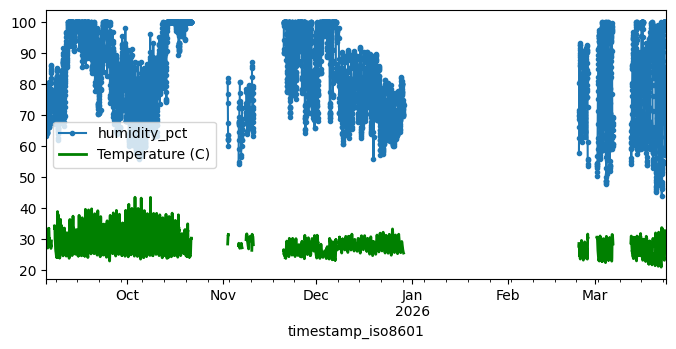

In [26]:
# Plotting
import matplotlib.pyplot as plt

# The last 5-day period
ax = df["humidity_pct"].plot(grid=True, marker='.', figsize=(8, 3.5))

df["temperature_c"].plot(
    ax=ax, color='green', linewidth=2, label="Temperature (C)"
)

# Add a legend to distinguish them
ax.legend()

In [27]:
# The gaps indicate times the board was off

In [28]:
df = df.interpolate(method="linear")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9603 entries, 2025-09-04 22:00:00+00:00 to 2026-03-23 23:00:00+00:00
Freq: 30min
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   humidity_pct   9603 non-null   float64
 1   lux_lx         9603 non-null   float64
 2   pressure_pa    9603 non-null   float64
 3   temperature_c  9603 non-null   float64
dtypes: float64(4)
memory usage: 633.2 KB


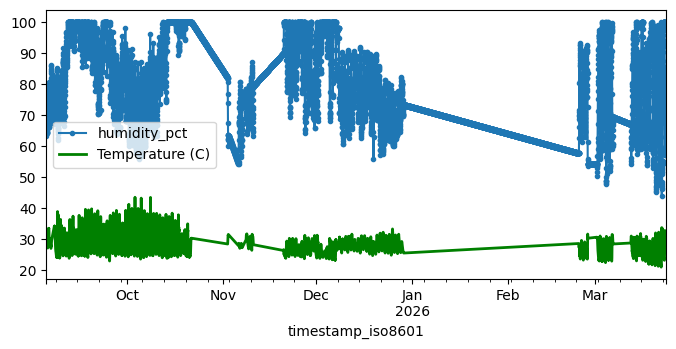

In [29]:
# The last 5-day period
ax = df["humidity_pct"].plot(grid=True, marker='.', figsize=(8, 3.5))

df["temperature_c"].plot(
    ax=ax, color='green', linewidth=2, label="Temperature (C)"
)
# Add a legend to distinguish them
ax.legend()

# Feature Engineering
We include the following features:
1. `sine_hour` - This captures the cyclical nature of the hour of the day. e.g. when taking the sine of the hour of the day, 23:00 is closer to 00:00 as it should be.
2. `cos_hour` - Similar to the above.
3. `temperature_delta` -  The difference between the temperature at the current timestamp and the timestamp immediately before.
4. `temp_mean_6h` - The average temperature over the past 6 hours at this current timestamp.
5. `temp_humidity_6h` - The average humidity over the past 6 hours at this current timestamp.

In [30]:
hour_of_day = df.index.hour
hour_of_day

Index([22, 22, 23, 23,  0,  0,  1,  1,  2,  2,
       ...
       18, 19, 19, 20, 20, 21, 21, 22, 22, 23],
      dtype='int32', name='timestamp_iso8601', length=9603)

In [31]:
import numpy as np

df["sine_hour"] = np.sin(2 * np.pi * hour_of_day / 24)
df["cos_hour"] = np.cos(2 * np.pi * hour_of_day / 24)
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour
timestamp_iso8601,,,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483,-0.500000,0.866025
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315,-0.500000,0.866025
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943,-0.258819,0.965926
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356,-0.258819,0.965926
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615,0.000000,1.000000


In [32]:
df["delta_temperature"] = df["temperature_c"] - df["temperature_c"].shift(1)
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature
timestamp_iso8601,,,,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483,-0.500000,0.866025,NaN
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315,-0.500000,0.866025,0.174832
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943,-0.258819,0.965926,2.232628
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356,-0.258819,0.965926,-0.260587
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615,0.000000,1.000000,-0.584741


In [33]:
# Since the first row will be null, we fill it with the mean for this column
df['delta_temperature'].fillna(df['delta_temperature'].mean(), inplace=True)
df.head()

/var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/ipykernel_60672/1216042316.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['delta_temperature'].fillna(df['delta_temperature'].mean(), inplace=True)


,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature
timestamp_iso8601,,,,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483,-0.500000,0.866025,-0.000073
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315,-0.500000,0.866025,0.174832
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943,-0.258819,0.965926,2.232628
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356,-0.258819,0.965926,-0.260587
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615,0.000000,1.000000,-0.584741


In [34]:
df["temp_mean_6h"] = df["temperature_c"].rolling(window=12, min_periods=1).mean()
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h
timestamp_iso8601,,,,,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483,-0.500000,0.866025,-0.000073,28.172483
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315,-0.500000,0.866025,0.174832,28.259899
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943,-0.258819,0.965926,2.232628,29.033247
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356,-0.258819,0.965926,-0.260587,29.354774
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615,0.000000,1.000000,-0.584741,29.430743


In [35]:
df["humidity_mean_6h"] = df["humidity_pct"].rolling(window=12, min_periods=1).mean()
df.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h,humidity_mean_6h
timestamp_iso8601,,,,,,,,,
2025-09-04 22:00:00+00:00,63.341935,26.594607,100973.617845,28.172483,-0.500000,0.866025,-0.000073,28.172483,63.341935
2025-09-04 22:30:00+00:00,69.947520,42.181484,100969.579486,28.347315,-0.500000,0.866025,0.174832,28.259899,66.644727
2025-09-04 23:00:00+00:00,75.398518,97.414887,100973.551907,30.579943,-0.258819,0.965926,2.232628,29.033247,69.562658
2025-09-04 23:30:00+00:00,76.887413,97.793978,101008.485453,30.319356,-0.258819,0.965926,-0.260587,29.354774,71.393847
2025-09-05 00:00:00+00:00,79.289795,97.822113,101026.242403,29.734615,0.000000,1.000000,-0.584741,29.430743,72.973036


## Normalizing

In [36]:
df.describe()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h,humidity_mean_6h
count,9603.000000,9603.000000,9603.000000,9603.000000,9603.000000,9.603000e+03,9603.000000,9603.000000,9603.000000
mean,77.350229,1234.400467,101100.565190,27.849756,-0.000131,2.809514e-04,-0.000073,27.849830,77.346326
std,13.747872,3817.896090,128.425995,2.626323,0.707075,7.072122e-01,0.553313,2.317293,13.307023
min,43.853953,0.000000,100635.793644,21.012534,-1.000000,-1.000000e+00,-4.365562,21.480952,48.959132
25%,66.196984,0.430569,101024.842850,26.136780,-0.707107,-7.071068e-01,-0.119287,26.290017,66.748205
50%,74.361444,8.027700,101127.680136,27.537704,0.000000,6.123234e-17,0.001131,27.605017,74.442612
75%,89.040046,42.168855,101183.035688,29.004751,0.707107,7.071068e-01,0.001131,28.971137,88.460771
max,100.000000,28891.834070,101492.141722,43.539995,1.000000,1.000000e+00,4.937021,39.408742,100.000000


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Identify numerical columns to scale, excluding 'temperature_c'
columns_to_scale = df.select_dtypes(include='number').columns.drop('temperature_c')

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

In [39]:
df.describe()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h,humidity_mean_6h
count,9.603000e+03,9.603000e+03,9.603000e+03,9603.000000,9.603000e+03,9.603000e+03,9.603000e+03,9.603000e+03,9.603000e+03
mean,-1.775802e-16,7.103208e-17,1.669017e-13,27.849756,-1.479835e-17,5.660369e-17,1.225488e-18,3.374024e-16,-4.143538e-17
std,1.000052e+00,1.000052e+00,1.000052e+00,2.626323,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-2.436597e+00,-3.233364e-01,-3.619172e+00,21.012534,-1.414166e+00,-1.414474e+00,-7.890145e+00,-2.748556e+00,-2.133360e+00
25%,-8.113129e-01,-3.232236e-01,-5.896492e-01,26.136780,-9.999118e-01,-1.000300e+00,-2.154671e-01,-6.731533e-01,-7.964721e-01
50%,-2.174112e-01,-3.212336e-01,2.111438e-01,27.537704,1.854016e-04,-3.972868e-04,2.176656e-03,-1.056517e-01,-2.182205e-01
75%,8.503444e-01,-3.122908e-01,6.421970e-01,29.004751,1.000283e+00,9.995056e-01,2.176656e-03,4.839118e-01,8.352750e-01
max,1.647597e+00,7.244533e+00,3.049203e+00,43.539995,1.414536e+00,1.413679e+00,8.923257e+00,4.988369e+00,1.702473e+00


# Creating the Datasets used by the Model

## Define Input Window Size and Prediction Window Size
We want to use the previous 24 hours of data to predict the next 12 hours of temperatures.

In [40]:
sample_size_in_hrs = 0.5 # we resampled to 30-min chunks
window_size_in_hrs = 24

# since each instance is a 30-min period, and we want a 24hr window
seq_length = int(window_size_in_hrs / sample_size_in_hrs)

## Train, Test Split
We use 80% of the data to train. Then the remaining 20% is then split into equal 10% segments. **No shuffling is done as the time series data needs to stay in chronological order**.

In [41]:
from sklearn.model_selection import train_test_split

# First split: 80% and 20%
df_train, df_temp = train_test_split(df, test_size=0.2,
                                     random_state=42, shuffle=False)

# Second split: split the remaining 20% into two 10% parts
df_valid, df_test = train_test_split(df_temp, test_size=0.5,
                                     random_state=42, shuffle=False)

print(f"Train: {len(df_train)}")
print(f"Valid: {len(df_valid)}")
print(f"Test: {len(df_test)}")


Train: 7682
Valid: 960
Test: 961


In [42]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7682 entries, 2025-09-04 22:00:00+00:00 to 2026-02-11 22:30:00+00:00
Freq: 30min
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   humidity_pct       7682 non-null   float64
 1   lux_lx             7682 non-null   float64
 2   pressure_pa        7682 non-null   float64
 3   temperature_c      7682 non-null   float64
 4   sine_hour          7682 non-null   float64
 5   cos_hour           7682 non-null   float64
 6   delta_temperature  7682 non-null   float64
 7   temp_mean_6h       7682 non-null   float64
 8   humidity_mean_6h   7682 non-null   float64
dtypes: float64(9)
memory usage: 600.2 KB


In [43]:
df_train.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h,humidity_mean_6h
timestamp_iso8601,,,,,,,,,
2025-09-04 22:00:00+00:00,-1.018996,-0.316370,-0.988538,28.172483,-0.706990,1.224229,-1.224736e-19,0.139244,-1.052461
2025-09-04 22:30:00+00:00,-0.538490,-0.312287,-1.019985,28.347315,-0.706990,1.224229,3.161219e-01,0.176970,-0.804249
2025-09-04 23:00:00+00:00,-0.141972,-0.297820,-0.989051,30.579943,-0.365876,1.365496,4.035363e+00,0.510716,-0.584960
2025-09-04 23:30:00+00:00,-0.033666,-0.297720,-0.717024,30.319356,-0.365876,1.365496,-4.708510e-01,0.649475,-0.447342
2025-09-05 00:00:00+00:00,0.141089,-0.297713,-0.578751,29.734615,0.000185,1.413679,-1.056723e+00,0.682259,-0.328662


## Converting DataFrames to Timeseries Datasets

In [44]:
import tensorflow as tf

In [45]:
def split_inputs_and_targets(
    multivariable_series,
    ahead=24, # the next 24 30-minute time slots (12 hours)
    target_col=3):
  return multivariable_series[:, :-ahead], multivariable_series[:, -ahead:, target_col]

In [46]:
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_train.to_numpy(),
    targets=None,
    sequence_length=seq_length + 24,
    batch_size=32,
    shuffle=True,
    seed=42
).map(split_inputs_and_targets)

train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, None, 9), dtype=tf.float64, name=None), TensorSpec(shape=(None, None), dtype=tf.float64, name=None))>

In [47]:
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_valid.to_numpy(),
    targets=None,
    sequence_length=seq_length + 24,
    batch_size=32
).map(split_inputs_and_targets)
valid_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, None, 9), dtype=tf.float64, name=None), TensorSpec(shape=(None, None), dtype=tf.float64, name=None))>

In [48]:
BATCH_SIZE = 32
seq_length = 48  # Fixed length for STM32 compatibility
num_features = df_train.shape[1]

def preprocess(x, y):
    # x shape: (batch, seq_length+24, num_features)
    # Slice to fixed length
    x = x[:, :seq_length, :]  # Keep first seq_length steps
    # Pad if shorter (unlikely here, but safe)
    current_len = tf.shape(x)[1]
    pad_len = seq_length - current_len
    x = tf.pad(x, [[0, 0], [0, pad_len], [0, 0]])  # Pad along time axis
    return x, y

# Apply fixed-length preprocessing
train_ds = train_ds.map(preprocess)
valid_ds = valid_ds.map(preprocess)


# Build and Compile the Model

## I Should Use Keras Tuner here once i get the base model to run

## Definition

In [49]:
# model = tf.keras.Sequential([
#     tf.keras.layers.SimpleRNN(32, return_sequences=True, input_shape=(48, 9)),
#     tf.keras.layers.SimpleRNN(32),
#     tf.keras.layers.Dense(24)
# ])

In [50]:
# early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae",
#                                                              patience=10,
#                                                              restore_best_weights=True)
# optimizer = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)

In [51]:
# model.compile(
#     loss=tf.keras.losses.Huber(),
#     optimizer=optimizer,
#     metrics=["mae"]
# )

## Training

In [52]:
# history = model.fit(
#     train_ds, validation_data=valid_ds,
#     epochs=500, callbacks=[early_stopping_cb]
# )

## Using Keras Tuner to Find Optimal Hyperparameters

In [53]:
# !pip install keras_tuner --upgrade

In [54]:
import keras_tuner as kt

num_features = df_train.shape[1]

# Assume df_train and seq_length are defined globally
# Example:
# seq_length = 48  # Fixed sequence length for STM32 compatibility
# num_features = df_train.shape[1]


def build_model(hp):
    n_hidden = hp.Int('n_hidden', min_value=0, max_value=3, default=2)
    n_neurons = hp.Int('n_neurons', min_value=16, max_value=64)
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    optimizer_choice = hp.Choice('optimizer', values=["sgd", "adam"])

    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9) \
        if optimizer_choice == "sgd" else tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(seq_length, num_features)))  # <-- Fix

    # First RNN layer
    model.add(tf.keras.layers.SimpleRNN(
        units=32,
        return_sequences=(n_hidden > 0),
        unroll=True
    ))

    # Additional hidden RNN layers
    for i in range(n_hidden):
        is_last_rnn = (i == n_hidden - 1)
        model.add(tf.keras.layers.SimpleRNN(
            units=n_neurons,
            return_sequences=not is_last_rnn,
            unroll=True
        ))

    model.add(tf.keras.layers.Dense(24))
    model.compile(loss=tf.keras.losses.Huber(), optimizer=optimizer, metrics=["mae"])


    return model


In [55]:
random_search_tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=5,
    overwrite=True,
    directory="rnn_model",
    project_name="random_search_rnn",
    seed=42
)

In [57]:
def set_static_input_shape(x, y):
    # x is expected to have shape (batch_size, seq_length, num_features)
    # The batch dimension can remain None (dynamic batch size), but the sequence length must be static.
    x.set_shape([None, seq_length, num_features])
    return x, y

# Apply this shape-setting map to the datasets before starting the search.
train_ds = train_ds.map(set_static_input_shape)
valid_ds = valid_ds.map(set_static_input_shape)

random_search_tuner.search(train_ds, epochs=20, validation_data=valid_ds)

Trial 5 Complete [00h 01m 28s]
val_mae: 6.4519267082214355

Best val_mae So Far: 1.5518543720245361
Total elapsed time: 00h 05m 29s


In [58]:
model = random_search_tuner.get_best_models(num_models=1)[0]
model.summary()

/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 48, 32)         │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 27)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,636 (14.20 KB)

 Trainable params: 3,636 (14.20 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 2 summary
Hyperparameters:
n_hidden: 1
n_neurons: 27
learning_rate: 0.00905127409782462
optimizer: adam
Score: 1.5518543720245361
Traceback (most recent call last):
  File "/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/keras_tuner/src

# Training the Best Model Found by the Tuner

# Using the Model to Make Predictions

In [60]:
def predict_12_hours(model, input_df, seq_length, start_idx, target_col_name,
                     target_col_idx, window_size_in_hrs, scaler):
  X = input_df.to_numpy()[np.newaxis, start_idx:start_idx+seq_length]
  print(f"Shape of Input Data: {X.shape}")

  Y_pred = model.predict(X)[0]
  print(f"Model's Original Prediction (Normalized): {Y_pred}")

  actual_next_12_hrs = input_df[start_idx+seq_length:
                                start_idx+seq_length+window_size_in_hrs][target_col_name].to_numpy()
  print(f"Actual Next 12 Hours: {actual_next_12_hrs}")

  # Calculating the predictions in degrees celcius
  temp_mean = scaler.mean_[target_col_idx]
  temp_std = scaler.scale_[target_col_idx]

  print(temp_mean, temp_std)

  Y_pred_deg = (Y_pred * temp_std) + temp_mean
  actual_next_12_hr_deg = (actual_next_12_hrs * temp_std) + temp_mean

  for i in range(window_size_in_hrs):
    model_pred_in_deg = Y_pred_deg[i]
    actual_in_deg = actual_next_12_hr_deg[i]
    pred_error = model_pred_in_deg - actual_in_deg

    print(f"{(i+1) * 30} MINUTES INTO THE FUTURE!")
    print(f"Model Prediction: {model_pred_in_deg} degrees celcius.")
    print(f"Actual Value: {actual_in_deg} degrees celcius.")
    print(f"Prediction Error: {pred_error} degrees celcius.")
    print('*'*20)

  return Y_pred_deg, actual_next_12_hr_deg

In [61]:
Y_pred_deg, actual_val_deg = predict_12_hours(model, df_valid, seq_length, 0, "temperature_c",
                 3, window_size_in_hrs, scaler)

Shape of Input Data: (1, 48, 9)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Model's Original Prediction (Normalized): [27.289894 27.41209  27.422035 27.398748 27.420368 27.452765 27.483309
 27.540602 27.587032 27.564417 27.548382 27.539375 27.551321 27.592144
 27.625443 27.638489 27.59885  27.597717 27.584015 27.582035 27.540033
 27.53952  27.53846  27.488262]
Actual Next 12 Hours: [28.03661077 28.03774207 28.03887338 28.04000469 28.041136   28.04226731
 28.04339862 28.04452992 28.04566123 28.04679254 28.04792385 28.04905516
 28.05018646 28.05131777 28.05244908 28.05358039 28.0547117  28.055843
 28.05697431 28.05810562 28.05923693 28.06036824 28.06149955 28.06263085]
-0.00013108601948376547 0.7070380642902905
30 MINUTES INTO THE FUTURE!
Model Prediction: 19.29486281596245 degrees celcius.
Actual Value: 19.822819919607642 degrees celcius.
Prediction Error: -0.5279571036451927 degrees celcius.
********************
60 MINUTES INTO THE FUTURE!
Model Prediction: 19.38126017891339 degrees celcius.
A

# Evaluating the model on the test set

In [62]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 961 entries, 2026-03-03 23:00:00+00:00 to 2026-03-23 23:00:00+00:00
Freq: 30min
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   humidity_pct       961 non-null    float64
 1   lux_lx             961 non-null    float64
 2   pressure_pa        961 non-null    float64
 3   temperature_c      961 non-null    float64
 4   sine_hour          961 non-null    float64
 5   cos_hour           961 non-null    float64
 6   delta_temperature  961 non-null    float64
 7   temp_mean_6h       961 non-null    float64
 8   humidity_mean_6h   961 non-null    float64
dtypes: float64(9)
memory usage: 75.1 KB


In [63]:
test_ds = tf.keras.utils.timeseries_dataset_from_array(
    df_test.to_numpy(),
    targets=None,
    sequence_length=seq_length + 24,  # same as in training
    batch_size=32
).map(split_inputs_and_targets)
test_ds = test_ds.map(preprocess)
test_ds = test_ds.map(set_static_input_shape)

In [64]:
import tensorflow as tf
import numpy as np # Ensure numpy is available for astype

# Ensure df_test data is float32 from the start
test_data_np_float32 = df_test.to_numpy().astype(np.float32)

# Define a single comprehensive mapping function for robustness
def create_dataset_element_batched(batched_full_sequence):
    # Ensure dtype consistency for the entire sequence batch
    batched_full_sequence = tf.cast(batched_full_sequence, tf.float32)

    # Split into input features (seq_length) and target values (ahead)
    # The first dimension is batch_size
    inputs = batched_full_sequence[:, :seq_length, :]
    # target_col_idx is implicitly 3 from previous function calls
    targets = batched_full_sequence[:, seq_length : seq_length + 24, 3]

    # Explicitly set static shapes for inputs and targets using tf.ensure_shape
    # The batch dimension will be None for dynamic batching
    inputs = tf.ensure_shape(inputs, (None, seq_length, num_features))
    targets = tf.ensure_shape(targets, (None, 24)) # 24 is the prediction horizon

    return inputs, targets

# Recreate test_ds with the single, comprehensive mapping function
# `timeseries_dataset_from_array` will produce batches of full sequences (seq_length + 24)
test_ds = tf.keras.utils.timeseries_dataset_from_array(
    test_data_np_float32,
    targets=None, # Process full sequences within the map function
    sequence_length=seq_length + 24,
    batch_size=32
)

# Apply the comprehensive mapping function
test_ds = test_ds.map(create_dataset_element_batched)

# Now evaluate the model on the refined test_ds
results = model.evaluate(test_ds)

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.8957 - mae: 2.3831


In [65]:
test_mae = results[1]
test_mae

2.3831276893615723

In [66]:
test_mae_deg = (test_mae * scaler.scale_[3])
test_mae_deg

np.float64(1.6849619884427987)

# Preparing the Model for Deployment on the Embedded Board

## Quantizing, Pruning and Saving the TFLite Model

In [67]:
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]


# # Fix for TensorArray ops
# converter.target_spec.supported_ops = [
#     tf.lite.OpsSet.TFLITE_BUILTINS,
#     tf.lite.OpsSet.SELECT_TF_OPS
# ]
# converter._experimental_lower_tensor_list_ops = False


# quantized_model = converter.convert()
# with open('quantized_rnn_model.tflite', 'wb') as f:
#   f.write(quantized_model)

In [68]:
# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]

# # Define a representative dataset for full integer quantization
# def representative_dataset():
#     for x, y in train_ds.take(100):  # Use a small subset of the training data
#         yield [tf.cast(x, tf.float32)] # Yield input data as a list of Tensors

# converter.representative_dataset = representative_dataset

# # Explicitly set input and output types to INT8 for full integer quantization
# # This is what will force the I/O to be INT8 if possible.
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8

# # Fix for TensorArray ops
# converter.target_spec.supported_ops = [
#     tf.lite.OpsSet.TFLITE_BUILTINS_INT8 # This ensures internal ops are INT8
# ]
# converter._experimental_lower_tensor_list_ops = True

# quantized_model = converter.convert()
# with open('quantized_rnn_model.tflite', 'wb') as f:
#   f.write(quantized_model)

In [69]:
### QUANTIZATION  ###
# Now we move onto quantizing the model
# we first set up some useful helper functions
# -----------------------------
# Utility: human-readable byte sizes
# -----------------------------
def format_bytes(number_of_bytes: int) -> str:
    unit_labels: List[str] = ["B", "KB", "MB", "GB", "TB"]
    value: float = float(number_of_bytes)
    unit_index: int = 0
    while value >= 1024.0 and unit_index < len(unit_labels) - 1:
        value /= 1024.0
        unit_index += 1
    return f"{value:.2f} {unit_labels[unit_index]}"

# -----------------------------
# Utility: describe how calibration coverage compares to int8 dynamic range
# -----------------------------
def describe_int8_dynamic_range(calibration_pool: np.ndarray, scale: float, zero_point: int) -> None:
    qmin, qmax = np.iinfo(np.int8).min, np.iinfo(np.int8).max
    int8_min: float = scale * (qmin - zero_point)
    int8_max: float = scale * (qmax - zero_point)
    flattened = calibration_pool.reshape(-1)
    dataset_min: float = float(flattened.min())
    dataset_max: float = float(flattened.max())
    pct_1: float = float(np.quantile(flattened, 0.01))
    pct_99: float = float(np.quantile(flattened, 0.99))
    print(f"[TFLite] calibration 1%-99%: [{pct_1:.4f}, {pct_99:.4f}]")
    print(f"[TFLite] int8 normalized span: [{int8_min:.4f}, {int8_max:.4f}]")
    print(f"[TFLite] calibration span:  [{dataset_min:.4f}, {dataset_max:.4f}]")

# -----------------------------
# Utility: run TFLite model and compute MAE on a batch of samples
# Handles both float and int8 models by reading quant params dynamically.
# -----------------------------
def evaluate_tflite_regression_mae(
    tflite_model_path: str,
    input_array: np.ndarray,
    target_array: np.ndarray,
    max_samples: int = 1000,
) -> float:
    """Evaluates MAE of a TFLite model on a subset of the provided data.

    Handles quantized int8 input/output by using the interpreter's scale and zero-point.
    """
    interpreter: tf.lite.Interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    # Shapes and quantization parameters
    input_scale: float = input_details["quantization"][0]
    input_zero_point: int = input_details["quantization"][1]
    output_scale: float = output_details["quantization"][0]
    output_zero_point: int = output_details["quantization"][1]
    is_input_int8: bool = (input_details["dtype"] == np.int8)
    is_output_int8: bool = (output_details["dtype"] == np.int8)
    # print quantization info for deployment parity on STM32
    print("[TFLite] input dtype:", input_details["dtype"], "scale:", input_scale, "zero_point:", input_zero_point)
    print("[TFLite] output dtype:", output_details["dtype"], "scale:", output_scale, "zero_point:", output_zero_point)
    if is_input_int8 and 'quantization_calibration_sequences' in globals():
        describe_int8_dynamic_range(quantization_calibration_sequences, input_scale, input_zero_point)
    # Cap samples to avoid very long runs in notebooks
    number_of_samples: int = min(max_samples, input_array.shape[0])
    per_sample_mae: List[float] = []
    for i in range(number_of_samples):
        sample_input: np.ndarray = input_array[i:i+1]
        true_values: np.ndarray = np.asarray(target_array[i], dtype=np.float32).reshape(-1)
        if is_input_int8:
            quantized_input: np.ndarray = np.round(sample_input / input_scale + input_zero_point).astype(np.int8)
            interpreter.set_tensor(input_details["index"], quantized_input)
        else:
            interpreter.set_tensor(input_details["index"], sample_input.astype(np.float32))
        interpreter.invoke()
        model_output: np.ndarray = interpreter.get_tensor(output_details["index"])
        if is_output_int8:
            dequantized_output = output_scale * (model_output.astype(np.float32) - output_zero_point)
        else:
            dequantized_output = model_output.astype(np.float32)
        predicted_values: np.ndarray = np.asarray(dequantized_output).reshape(-1)
        if predicted_values.shape != true_values.shape:
            raise ValueError(
                f"Shape mismatch between predictions {predicted_values.shape} and targets {true_values.shape}"
            )
        sample_mae: float = float(np.mean(np.abs(predicted_values - true_values)))
        per_sample_mae.append(sample_mae)
    mean_absolute_error: float = float(np.mean(per_sample_mae))
    return mean_absolute_error


# -----------------------------
# Utility: quick Keras MAE helper (FP32 path)
# -----------------------------
def evaluate_keras_mae(keras_model, X, y):
    loss_value, mae_value = keras_model.evaluate(X, y, verbose=0)
    return float(mae_value)

In [70]:
train_ds.take(5)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 48, 9), dtype=tf.float64, name=None), TensorSpec(shape=(None, None), dtype=tf.float64, name=None))>

In [71]:
from typing import Dict, Iterable, List, Optional, Tuple, Union
# -----------------------------
# Representative dataset function for INT8 calibration
# Why:
#   The converter needs real input ranges to compute per-tensor scales for int8.
#   We should ideally feed a few hundred data examples that look like real inference inputs.
# Notes:
#   - Use the same normalization you used during training.
#   - Keep the batch shape [1, time, features] as the interpreter will.
# -----------------------------
def representative_dataset():
    for x, y in train_ds.take(100):  # Use a small subset of the training data
        yield [tf.cast(x, tf.float32)] # Yield input data as a list of Tensors (should be float32)

def convert_to_tflite_float32(keras_model):
    float_converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    return float_converter.convert()

# -----------------------------
# INT8 post-training quantization
#   - from_keras_model(best_pruned_model): start with our trained, pruned model
#   - optimizations=[DEFAULT]: tell converter to try size and latency improvements
#   - representative_dataset: feed real data for proper scaling
#   - supported_ops=[INT8]: force only built-in int8 ops, compatible with MCUs
#   - inference_input_type/int8: enforce int8 tensors at runtime
#   - convert(): produce a FlatBuffer with per-tensor scales and zero-points
# -----------------------------
def convert_to_tflite_int8(keras_model):
    int8_converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    int8_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    int8_converter.representative_dataset = representative_dataset
    int8_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    int8_converter.inference_input_type = tf.int8
    int8_converter.inference_output_type = tf.int8
    return int8_converter.convert()

In [72]:
# -----------------------------
# Do the conversions and print sizes
# -----------------------------
def estimate_sram_kb(tflite_bytes: bytes) -> float:
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    tensor_details = interpreter.get_tensor_details()

    def tensor_ram_bytes(detail):
        dtype = np.dtype(detail["dtype"])
        shape = detail.get("shape_signature", detail.get("shape"))
        shape = [dim if dim > 0 else 1 for dim in shape]
        return int(np.prod(shape)) * dtype.itemsize

    sram_bytes = sum(
        tensor_ram_bytes(detail)
        for detail in tensor_details
        if detail.get("buffer", 0) == 0 or detail.get("is_variable", False)
    )
    return sram_bytes / 1024

tflite_float32_bytes: bytes = convert_to_tflite_float32(model)
tflite_int8_bytes: bytes = convert_to_tflite_int8(model)

with open("quantized_rnn_model_float32.tflite", "wb") as f:
    f.write(tflite_float32_bytes)
with open("quantized_rnn_model_int8.tflite", "wb") as f:
    f.write(tflite_int8_bytes)

sram_float32_kb: float = estimate_sram_kb(tflite_float32_bytes)
sram_int8_kb: float = estimate_sram_kb(tflite_int8_bytes)
print(f"Float32 TFLite estimated SRAM: {sram_float32_kb:.2f} KB")
print(f"Int8 TFLite estimated SRAM: {sram_int8_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb/assets


INFO:tensorflow:Assets written to: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb/assets


Saved artifact at '/var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  5408598048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466652368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5412583056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5418001584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417996128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417992784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417997360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5412691760: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1774468015.748096 16873208 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774468015.748127 16873208 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774468015.749393 16873208 reader.cc:83] Reading SavedModel from: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb
I0000 00:00:1774468015.753152 16873208 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774468015.753174 16873208 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb
I0000 00:00:1774468015.791013 16873208 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1774468015.793608 16873208 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774468015.899254 16873208 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp3uu8lpjb
I0000 00:00:1774468015.965372 16

INFO:tensorflow:Assets written to: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp46kqk3pw/assets


INFO:tensorflow:Assets written to: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp46kqk3pw/assets


Saved artifact at '/var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp46kqk3pw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  5408598048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466652368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5412583056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5418001584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417996128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417992784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5417997360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5412691760: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1774468024.428542 16873208 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774468024.428566 16873208 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774468024.428949 16873208 reader.cc:83] Reading SavedModel from: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp46kqk3pw
I0000 00:00:1774468024.431930 16873208 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774468024.431944 16873208 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/x7/m1y0b5hs6lvdcp8n01m1fnp00000gn/T/tmp46kqk3pw
I0000 00:00:1774468024.467477 16873208 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774468024.568817 16873208 loader.cc:220] Running initiali

Float32 TFLite estimated SRAM: 81.92 KB
Int8 TFLite estimated SRAM: 33.11 KB


/Users/tevinachong/Documents/TinyML-Home-Weather-Forecasting/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## Reload the TFLite Model

In [73]:
# Load the TFLite model
# interpreter = tf.lite.Interpreter(model_path="quantized_rnn_model.tflite")
# interpreter = tf.lite.Interpreter(model_path="cnn_v3.tflite")
# interpreter.allocate_tensors()

# # Get input and output details (optional)
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()

# print("Model loaded successfully!")
# print("Input details:", input_details)
# print("Output details:", output_details)

In [74]:
interpreter = tf.lite.Interpreter(model_path="quantized_rnn_model_int8.tflite")
interpreter.allocate_tensors()

# Get input and output details (optional)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Model loaded successfully!")
print("Input details:", input_details)
print("Output details:", output_details)

Model loaded successfully!
Input details: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 48,  9], dtype=int32), 'shape_signature': array([-1, 48,  9], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.201686829328537, -89), 'quantization_parameters': {'scales': array([0.20168683], dtype=float32), 'zero_points': array([-89], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 649, 'shape': array([ 1, 24], dtype=int32), 'shape_signature': array([-1, 24], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.10838624835014343, -128), 'quantization_parameters': {'scales': array([0.10838625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [75]:

# Evaluating the size of the tflite model
import os

file_path = "quantized_rnn_model_int8.tflite"
size_in_bytes = os.path.getsize(file_path)
size_in_kb = size_in_bytes / 1024

size_in_mb = size_in_kb / 1024

print(f"Model size: {size_in_bytes} bytes ({size_in_kb:.2f} KB / {size_in_mb:.2f} MB)")


Model size: 328856 bytes (321.15 KB / 0.31 MB)


In [76]:
df_valid.head()

,humidity_pct,lux_lx,pressure_pa,temperature_c,sine_hour,cos_hour,delta_temperature,temp_mean_6h,humidity_mean_6h
timestamp_iso8601,,,,,,,,,
2026-02-11 23:00:00+00:00,-1.190241,-0.320053,0.686878,27.982308,-0.365876,1.365496,0.002177,0.054487,-1.226994
2026-02-11 23:30:00+00:00,-1.190661,-0.320052,0.687142,27.983439,-0.365876,1.365496,0.002177,0.054975,-1.227427
2026-02-12 00:00:00+00:00,-1.191081,-0.320050,0.687406,27.984571,0.000185,1.413679,0.002177,0.055464,-1.227861
2026-02-12 00:30:00+00:00,-1.191501,-0.320049,0.687670,27.985702,0.000185,1.413679,0.002177,0.055952,-1.228295
2026-02-12 01:00:00+00:00,-1.191921,-0.320048,0.687934,27.986833,0.366246,1.365496,0.002177,0.056440,-1.228729


## Using the TFLite Model to Make a Prediction

In [77]:
# Prepare input (same as Keras)
X = df_valid.to_numpy()[np.newaxis, :seq_length]  # shape: (1, seq_length, features)
X = X.astype(input_details[0]['dtype'])  # match TFLite dtype

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], X)

# Run inference
interpreter.invoke()

# Get prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
print("Prediction:", output_data)

Prediction: [[123 124 124 124 124 124 125 125 126 125 125 125 125 126 126 126 126 126
  125 126 125 125 125 125]]


In [78]:
X

array([[[-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  0,  1,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 27,  1,  0,  0,  0, -1],
        [-1,  0,  0, 28,  1,  0,  0,  0, -1],
        [-1,  0,  0, 28,  1,  0,  0,  0, -1],
        [-1,  0,  0, 28,  1,  0,  0,  0, -1],
        [-1,  0,  0, 28,  1,  0,  0,  0, -1],
        [-1,  0,  0, 28,  1, -1,  0,  0, -1],
        [-1,  0,  0, 28,  1, -1,  

## Evaluating the TFLite Model on the Test Dataset

In [79]:

import numpy as np

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

seq_length = 48  # or whatever your window size is
num_features = df_test.shape[1]

# Store predictions and true values
preds = []
trues = []

# Loop through test set windows
for start in range(len(df_test) - seq_length - 24 + 1):  # 24 is your prediction horizon
    X = df_test.to_numpy()[start:start+seq_length]
    X = X[np.newaxis, ...].astype(input_details[0]['dtype'])  # shape: (1, seq_length, features)

    interpreter.set_tensor(input_details[0]['index'], X)
    interpreter.invoke()
    y_pred = interpreter.get_tensor(output_details[0]['index'])[0]  # shape: (24,)
    preds.append(y_pred)

    # True values for the next 24 steps of the target column (e.g., temperature)
    y_true = df_test.iloc[start+seq_length:start+seq_length+24]['temperature_c'].to_numpy()
    trues.append(y_true)


In [80]:

preds = np.array(preds)
trues = np.array(trues)

# If you normalized your data, de-normalize predictions and trues here

mae = np.mean(np.abs(preds - trues))


In [81]:
print(f"TFLite Model Test MAE: {mae}")
print(f"TFLite Model Test MAE Degrees Celcius: {mae * scaler.scale_[3]}")

TFLite Model Test MAE: 97.86312198656273
TFLite Model Test MAE Degrees Celcius: 69.19295233478388
